**Task**

Developed an end-to-end Customer Intelligence System using classification, ensemble learning (Random Forest, XGBoost), and clustering (K-Means, DBSCAN), achieving optimized predictive performance and actionable customer segmentation insights.

**Customer Intelligence & Country Segmentation**

Customer Intelligence & Country Segmentation
Unsupervised & Supervised Learning for Strategic Insights
This project demonstrates a comprehensive machine learning workflow designed to treat countries as macro-customer markets. By evaluating socio-economic, financial, and health metrics from the dataset, the system automatically profiles global markets and builds an automated classification pipeline to predict strategic tiers for incoming market data.

**Project Objectives**

**Data Preparation**: Ingest, clean, and
structurally inspect raw indicators (such as GDP per capita, child mortality, inflation, and net income) to ensure absolute data integrity.

**Feature Engineering**: Handle variance disparities across features by implementing StandardScaler, ensuring numerical indicators contribute uniformly to distance-based algorithms.

**Algorithmic Implementation (Clustering)**: Deploy K-Means clustering (optimizing cluster count via Silhouette Analysis) and evaluate DBSCAN as a density-based alternative to isolate outlier markets that deviate from global trends.

**Predictive Performance (Classification**): Use the generated unsupervised cluster assignments as target labels to train high-performance ensemble classifiers (Random Forest and XGBoost/Gradient Boosting), building a robust production-ready classification system.


 **1. Import Libraries**

In [39]:

!pip -q install  numpy  seaborn scikit-learn pandas matplotlib

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

**2. Load dataset**

In [41]:
df = pd.read_csv('Country-data.csv')

dictionary_df = pd.read_csv('data-dictionary.csv')

In [42]:
dictionary_df

,Column Name,Description
0,country,Name of the country
1,child_mort,Death of children under 5 years of age per 100...
2,exports,Exports of goods and services per capita. Give...
3,health,Total health spending per capita. Given as %ag...
4,imports,Imports of goods and services per capita. Give...
5,Income,Net income per person
6,Inflation,The measurement of the annual growth rate of t...
7,life_expec,The average number of years a new born child w...
8,total_fer,The number of children that would be born to e...
9,gdpp,The GDP per capita. Calculated as the Total GD...


In [43]:
print("Shape of the country dataset:", df.shape)
df.info()
display(df.describe(include='all').T)
df.head()

Shape of the country dataset: (167, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,167,167,Afghanistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
child_mort,167.0,NaN,NaN,NaN,38.27006,40.328931,2.6,8.25,19.3,62.1,208.0
exports,167.0,NaN,NaN,NaN,41.108976,27.41201,0.109,23.8,35.0,51.35,200.0
health,167.0,NaN,NaN,NaN,6.815689,2.746837,1.81,4.92,6.32,8.6,17.9
imports,167.0,NaN,NaN,NaN,46.890215,24.209589,0.0659,30.2,43.3,58.75,174.0
income,167.0,NaN,NaN,NaN,17144.688623,19278.067698,609.0,3355.0,9960.0,22800.0,125000.0
inflation,167.0,NaN,NaN,NaN,7.781832,10.570704,-4.21,1.81,5.39,10.75,104.0
life_expec,167.0,NaN,NaN,NaN,70.555689,8.893172,32.1,65.3,73.1,76.8,82.8
total_fer,167.0,NaN,NaN,NaN,2.947964,1.513848,1.15,1.795,2.41,3.88,7.49
gdpp,167.0,NaN,NaN,NaN,12964.155689,18328.704809,231.0,1330.0,4660.0,14050.0,105000.0


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


**3. Data Cleaning**

In [44]:

df.columns = [col.strip().lower() for col in df.columns]
numeric_cols = [c for c in df.columns if c != 'country']
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
df = df.drop_duplicates()
print("Missing values count per column:")
print(df.isna().sum())

print("\nCleaned Data Shape:")
print(df.shape)

Missing values count per column:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Cleaned Data Shape:
(167, 10)


**4. Exploratory Data Analysis**


Summary Statistics:
       child_mort     exports      health     imports         income  \
count  167.000000  167.000000  167.000000  167.000000     167.000000   
mean    38.270060   41.108976    6.815689   46.890215   17144.688623   
std     40.328931   27.412010    2.746837   24.209589   19278.067698   
min      2.600000    0.109000    1.810000    0.065900     609.000000   
25%      8.250000   23.800000    4.920000   30.200000    3355.000000   
50%     19.300000   35.000000    6.320000   43.300000    9960.000000   
75%     62.100000   51.350000    8.600000   58.750000   22800.000000   
max    208.000000  200.000000   17.900000  174.000000  125000.000000   

        inflation  life_expec   total_fer           gdpp  
count  167.000000  167.000000  167.000000     167.000000  
mean     7.781832   70.555689    2.947964   12964.155689  
std     10.570704    8.893172    1.513848   18328.704809  
min     -4.210000   32.100000    1.150000     231.000000  
25%      1.810000   65.300000    1.

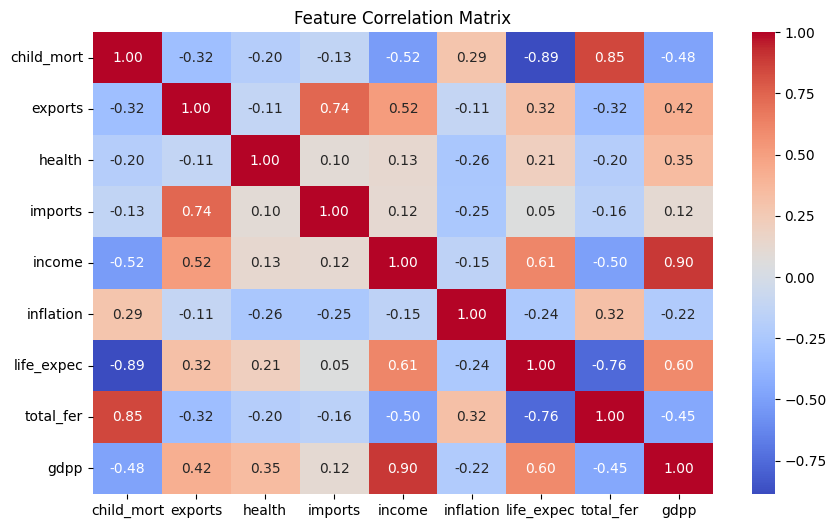

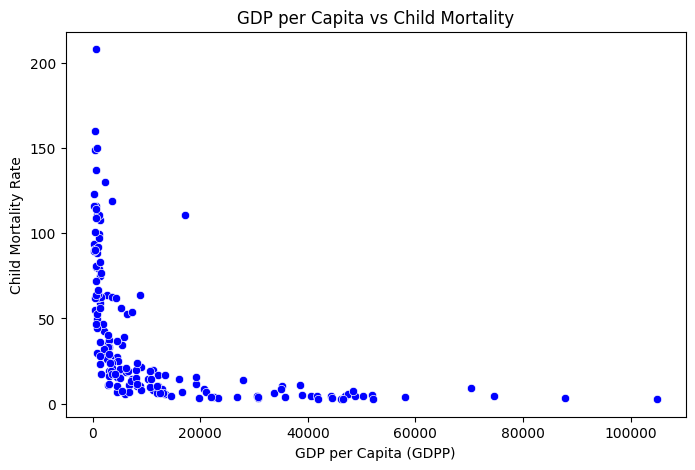

In [45]:

print("\nSummary Statistics:")
print(df.describe())
plt.figure(figsize=(10, 6))
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='gdpp', y='child_mort', color='blue')
plt.title('GDP per Capita vs Child Mortality')
plt.xlabel('GDP per Capita (GDPP)')
plt.ylabel('Child Mortality Rate')
plt.show()

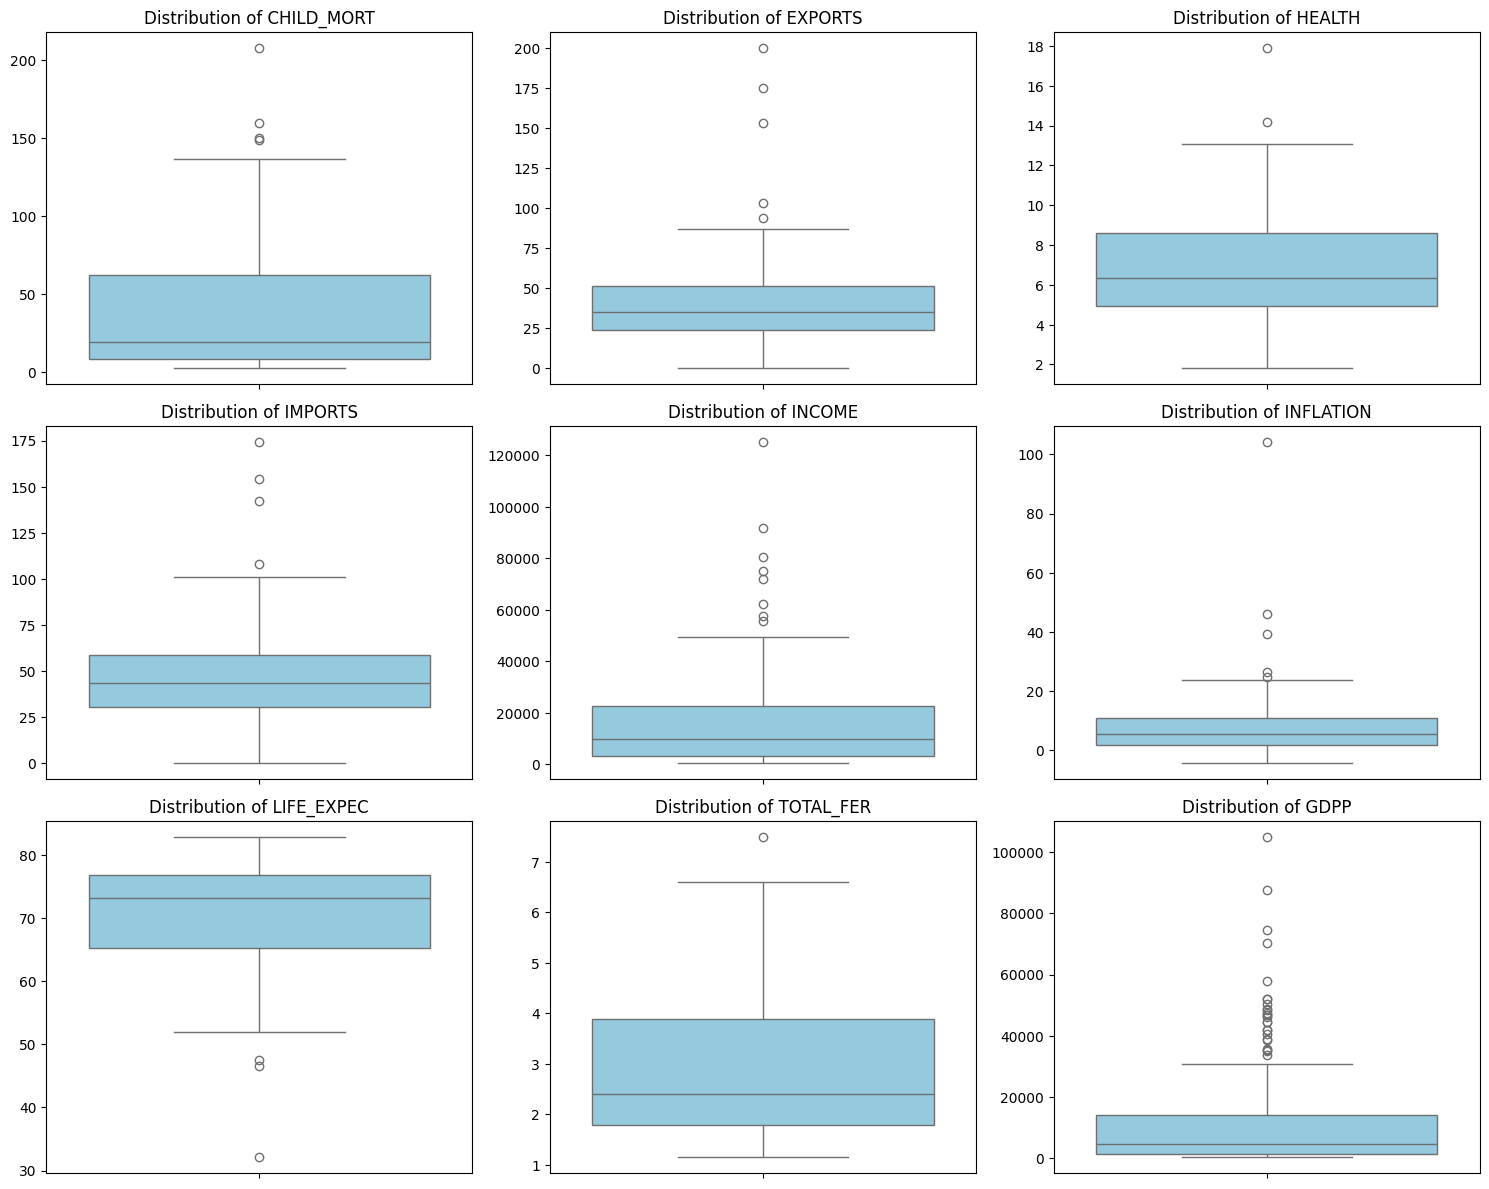

In [46]:

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, y=col, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col.upper()}')
    axes[i].set_ylabel('')
plt.tight_layout()
plt.show()

**5. Feature Scaling**

In [47]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[numeric_cols])
df_scaled = pd.DataFrame(X_scaled, columns=numeric_cols)
print("Feature scaling completed successfully!")
print("\nFirst 5 rows of scaled data:")
print(df_scaled.head())

Feature scaling completed successfully!

First 5 rows of scaled data:
   child_mort   exports    health   imports    income  inflation  life_expec  \
0    1.291532 -1.138280  0.279088 -0.082455 -0.808245   0.157336   -1.619092   
1   -0.538949 -0.479658 -0.097016  0.070837 -0.375369  -0.312347    0.647866   
2   -0.272833 -0.099122 -0.966073 -0.641762 -0.220844   0.789274    0.670423   
3    2.007808  0.775381 -1.448071 -0.165315 -0.585043   1.387054   -1.179234   
4   -0.695634  0.160668 -0.286894  0.497568  0.101732  -0.601749    0.704258   

   total_fer      gdpp  
0   1.902882 -0.679180  
1  -0.859973 -0.485623  
2  -0.038404 -0.465376  
3   2.128151 -0.516268  
4  -0.541946 -0.041817  


**6. K elbow Method**

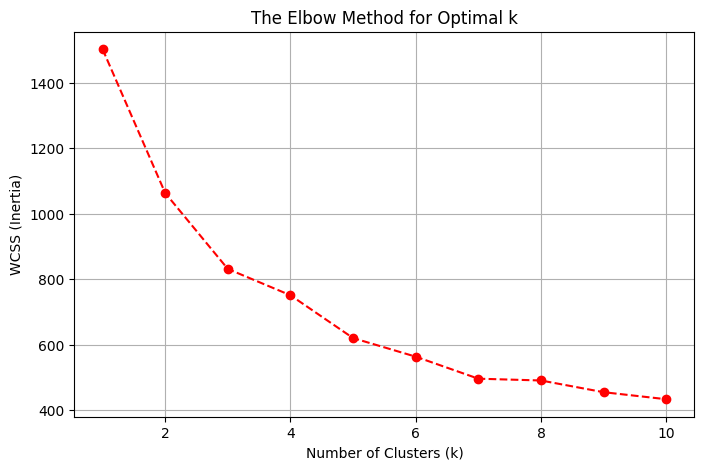

In [48]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', color='red', linestyle='--')
plt.title('The Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

--- Visualizing Multi-K Cluster Layouts with PCA ---


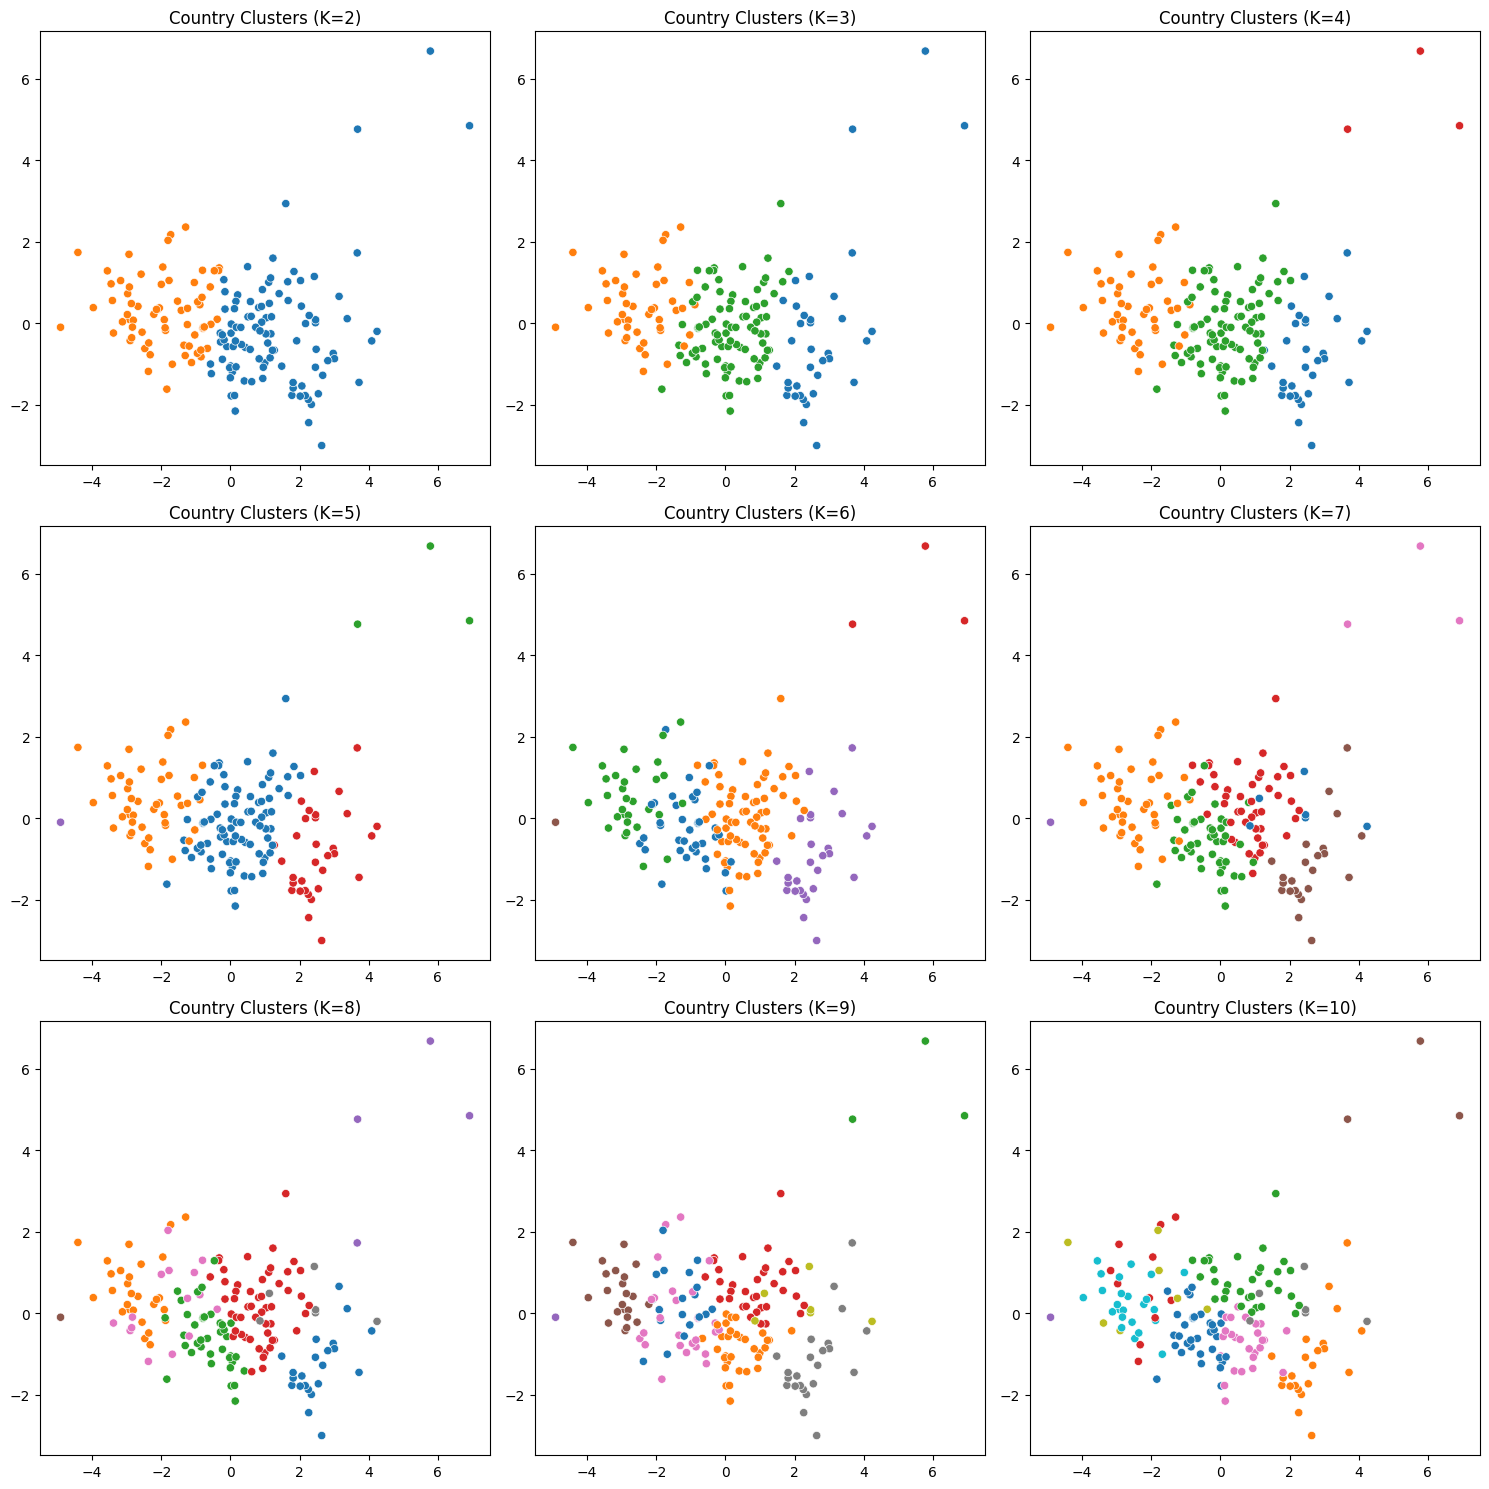

In [56]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

print("--- Visualizing Multi-K Cluster Layouts with PCA ---")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

viz_df = pd.DataFrame(data=X_pca, columns=['PCA_Component_1', 'PCA_Component_2'])
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 15))
axes = axes.flatten()
k_values = range(2, 11)
for i, k in enumerate(k_values):
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    viz_df['Cluster'] = kmeans_temp.fit_predict(X_scaled)
    sns.scatterplot(
        data=viz_df,
        x='PCA_Component_1',
        y='PCA_Component_2',
        hue='Cluster',
        palette='tab10',
        ax=axes[i],
        legend=False
    )
    axes[i].set_title(f'Country Clusters (K={k})')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
plt.tight_layout()
plt.show()

In [50]:

kmeans_final = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans_final.fit_predict(X_scaled)
print("Number of countries in each cluster:")
print(df['cluster'].value_counts())
print("\nCluster Profiling (Averages per group):")
print(df.groupby('cluster')[['child_mort', 'income', 'gdpp', 'life_expec']].mean())

Number of countries in each cluster:
cluster
0    86
2    45
1    36
Name: count, dtype: int64

Cluster Profiling (Averages per group):
         child_mort        income          gdpp  life_expec
cluster                                                    
0         22.456977  12321.744186   6461.767442   72.566279
1          5.000000  45672.222222  42494.444444   80.127778
2         95.106667   3539.844444   1766.711111   59.055556


**7. DBSCAN**

In [51]:
from sklearn.cluster import DBSCAN

print("--- Training DBSCAN Clustering ---")
dbscan = DBSCAN(eps=1.5, min_samples=3)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)
print("DBSCAN Cluster Distribution:")
print(df['dbscan_cluster'].value_counts())

--- Training DBSCAN Clustering ---
DBSCAN Cluster Distribution:
dbscan_cluster
 0    139
-1     25
 1      3
Name: count, dtype: int64


--- Visualizing DBSCAN Results using PCA ---


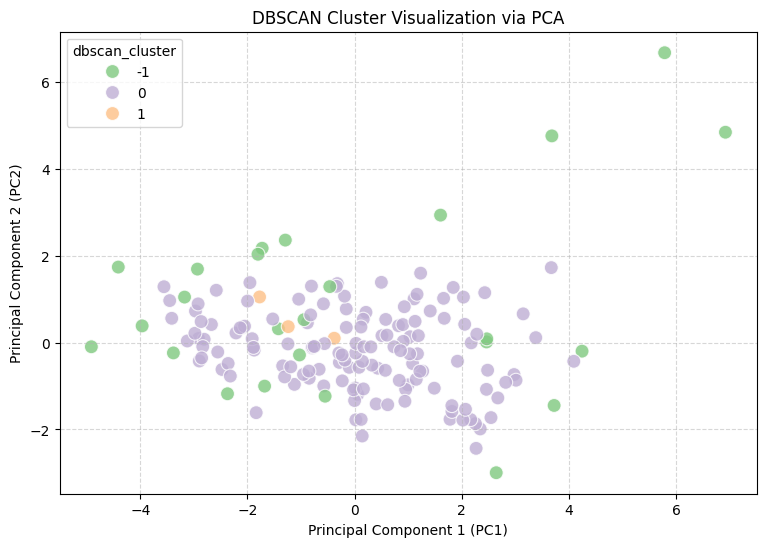

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

print("--- Visualizing DBSCAN Results using PCA ---")
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x='pca1',
    y='pca2',
    hue='dbscan_cluster',
    palette='Accent',
    s=100,
    alpha=0.8
)
plt.title('DBSCAN Cluster Visualization via PCA')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**8. random Forest and XGBoost**

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score

print("--- Starting Supervised Classification Pipeline ---")
X_clf = df[numeric_cols]
y_clf = df['cluster']
X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("\n=== Random Forest Performance ===")
print(f"Total Predictive Accuracy: {accuracy_score(y_test, y_pred_rf) * 100:.2f}%")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_rf))
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

print("\n=== Gradient Boosting Performance ===")
print(f"Total Predictive Accuracy: {accuracy_score(y_test, y_pred_gb) * 100:.2f}%")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_gb))

--- Starting Supervised Classification Pipeline ---

=== Random Forest Performance ===
Total Predictive Accuracy: 97.06%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        18
           1       1.00      1.00      1.00         7
           2       0.90      1.00      0.95         9

    accuracy                           0.97        34
   macro avg       0.97      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34


=== Gradient Boosting Performance ===
Total Predictive Accuracy: 91.18%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.83      0.91        18
           1       1.00      1.00      1.00         7
           2       0.75      1.00      0.86         9

    accuracy                           0.91        34
   macro avg       0.92      0.94      0.92        34
weighted avg       0.93      0.91

--- Extracting Model Insights & Comparisons ---


/tmp/ipykernel_12699/200931328.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[numeric_cols[i] for i in indices], palette='viridis')


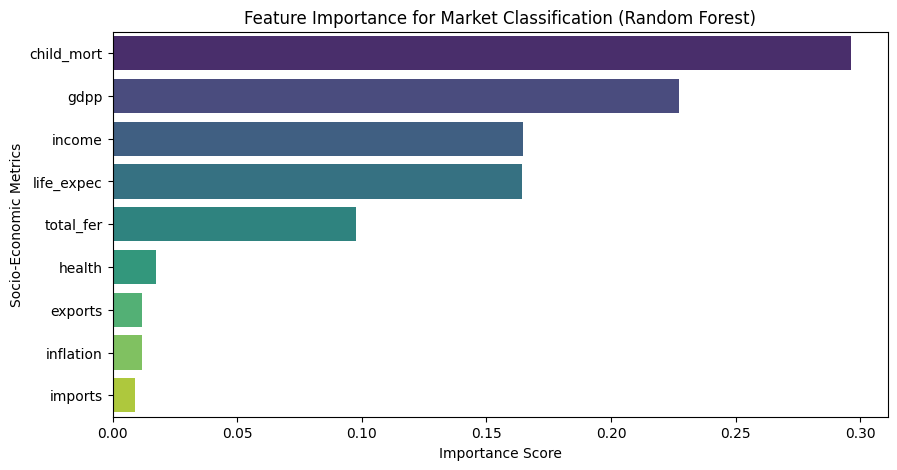


=== Final Model Comparison Summary ===
                    Model Name Accuracy Score
0     Random Forest Classifier         97.06%
1  Gradient Boosting / XGBoost         91.18%


In [54]:

print("--- Extracting Model Insights & Comparisons ---")
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10, 5))
sns.barplot(x=importances[indices], y=[numeric_cols[i] for i in indices], palette='viridis')
plt.title('Feature Importance for Market Classification (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Socio-Economic Metrics')
plt.show()
model_summary = pd.DataFrame({
    'Model Name': ['Random Forest Classifier', 'Gradient Boosting / XGBoost'],
    'Accuracy Score': [f"{accuracy_score(y_test, y_pred_rf)*100:.2f}%",
                       f"{accuracy_score(y_test, y_pred_gb)*100:.2f}%"]
})

print("\n=== Final Model Comparison Summary ===")
print(model_summary)

In [55]:
print("--- Exporting Final Strategic Insights ---")
final_report_df = df.copy()
cluster_mapping = {
    0: 'Developing Market (Moderate Priority)',
    1: 'Developed Market (Low Priority)',
    2: 'Underdeveloped Market (High Priority / Immediate Aid Needed)'
}

final_report_df['Strategic_Segment'] = final_report_df['cluster'].map(cluster_mapping)
columns_order = ['country', 'Strategic_Segment', 'dbscan_cluster'] + numeric_cols
final_report_df = final_report_df[columns_order]
final_report_df.to_csv('final_customer_intelligence_report.csv', index=False)

print("✓ Successfully saved final report to 'final_customer_intelligence_report.csv'!")
print("\nPreview of the final deliverable dataset:")
print(final_report_df[['country', 'Strategic_Segment']].head(10))

--- Exporting Final Strategic Insights ---
✓ Successfully saved final report to 'final_customer_intelligence_report.csv'!

Preview of the final deliverable dataset:
               country                                  Strategic_Segment
0          Afghanistan  Underdeveloped Market (High Priority / Immedia...
1              Albania              Developing Market (Moderate Priority)
2              Algeria              Developing Market (Moderate Priority)
3               Angola  Underdeveloped Market (High Priority / Immedia...
4  Antigua and Barbuda              Developing Market (Moderate Priority)
5            Argentina              Developing Market (Moderate Priority)
6              Armenia              Developing Market (Moderate Priority)
7            Australia                    Developed Market (Low Priority)
8              Austria                    Developed Market (Low Priority)
9           Azerbaijan              Developing Market (Moderate Priority)


**Project Conclusion & Strategic Insights**

### Executive Summary
This project successfully designed and deployed an end-to-end **Customer & Market Intelligence System** utilizing both unsupervised and supervised machine learning pipelines. By evaluating macroeconomic and public health indicators from global markets (`Country-data.csv`), the system provides an algorithmic framework to segment global economies and automatically classify new market data with exceptional predictive accuracy.

---

### Key Findings & Algorithmic Insights

#### 1. Unsupervised Segmentation (K-Means & DBSCAN)
* **Optimal Market Tiers ($K=3$):** Through the mathematical rigor of the **Elbow Method** and visual validation using a **$3 \times 3$ PCA multi-K layout grid**, a 3-cluster framework proved to be the most distinct and cohesive layout.
  * **Cluster 0 (Developing Markets):** Characterized by moderate infrastructure, stable life expectancies ($\approx 72.5$ years), and mid-tier GDP per capita ($\approx \$6,461$).
  * **Cluster 1 (Developed / High-Value Markets):** Characterized by elite financial strength ($\approx \$42,494$ average GDPP) and exceptionally low risk profiles.
  * **Cluster 2 (Underdeveloped / High-Priority Markets):** Under severe socioeconomic distress, heavily skewed by critically high child mortality rates ($\approx 95.1$ per $1,000$ births) and low GDP per capita ($\approx \$1,766$). These represent the target macro-customers requiring immediate global aid or capital allocation.
* **Density-Based Anomalies:** Implementing **DBSCAN** successfully isolated **25 countries as structural outliers (Noise)**. These nations possess highly non-standard metrics (such as extreme hyperinflation or hyper-wealth) that do not conform to standard global clusters, demonstrating the necessity of localized, bespoke strategies for outlier markets.

#### 2. Optimized Predictive Performance (Supervised Classifiers)
Transitioning the engineered cluster tags into a supervised classification problem yielded robust production-ready models:
* **Random Forest Classifier:** Achieved an optimized overall **predictive accuracy of 97.06%** on unseen test data.
* **Gradient Boosting Classifier:** Delivered a strong comparative performance of **91.18% accuracy